<center>Assignment 10 - Preprocessing stage</center>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

columns = ['engine_id','cycle','op_setting1','op_setting2','op_setting3'] + \
          ['sensor_' + str(i) for i in range(1,22)]

datasets = {
    "FD001": "train_FD001.txt",
    "FD002": "train_FD002.txt",
    "FD003": "train_FD003.txt",
    "FD004": "train_FD004.txt"
}

def create_sliding_windows(df, window_size):

    feature_cols = [col for col in df.columns
                    if col not in ['engine_id','cycle','RUL']]

    X = []
    y = []

    for engine in df['engine_id'].unique():

        engine_data = df[df['engine_id']==engine]

        data = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        for i in range(len(engine_data) - window_size):

            window = data[i:i+window_size].flatten()

            X.append(window)
            y.append(rul[i+window_size])

    return np.array(X), np.array(y), feature_cols

def process_dataset(dataset_name, file_path):

    print("\n====================================")
    print("Processing Dataset:", dataset_name)
    print("====================================")

    df = pd.read_csv(file_path, sep="\s+", header=None)
    df.columns = columns

    # ------------------------------
    # Compute RUL
    # ------------------------------

    df['RUL'] = df.groupby('engine_id')['cycle'].transform('max') - df['cycle']

    df['RUL'] = df['RUL'].clip(upper=125)

    # ------------------------------
    # Identify low variance sensors
    # ------------------------------

    sensor_cols = [col for col in df.columns if 'sensor_' in col]

    sensor_variance = df[sensor_cols].var()

    low_variance_sensors = sensor_variance[sensor_variance < 1e-3].index.tolist()

    print("Sensors removed:", low_variance_sensors)

    df = df.drop(columns=low_variance_sensors)

    # ------------------------------
    # Normalize sensor data
    # ------------------------------

    feature_cols = [col for col in df.columns
                    if col not in ['engine_id','cycle','RUL']]

    scaler = StandardScaler()

    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    # ------------------------------
    # Correlation Matrix
    # ------------------------------

    plt.figure(figsize=(12,8))

    corr = df[feature_cols].corr()

    sns.heatmap(corr, cmap='coolwarm')

    plt.title(f"Correlation Matrix - {dataset_name}")

    plt.show()

    # ------------------------------
    # Save processed dataset
    # ------------------------------

    save_path = f"processed_data/{dataset_name}_processed.csv"

    df.to_csv(save_path, index=False)

    print("Saved:", save_path)

    # ------------------------------
    # Create sliding windows
    # ------------------------------

    X, y, feature_cols = create_sliding_windows(df, window_size=40)

    print("Sliding window shape:", X.shape)

    # Convert to dataframe for CSV

    X_df = pd.DataFrame(X)

    y_df = pd.DataFrame(y, columns=['RUL'])

    X_file = f"sliding_windows/{dataset_name}_X.csv"
    y_file = f"sliding_windows/{dataset_name}_y.csv"

    X_df.to_csv(X_file, index=False)
    y_df.to_csv(y_file, index=False)

    print("Saved sliding windows:", X_file, y_file)

    return df



Processing Dataset: FD001
Sensors removed: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


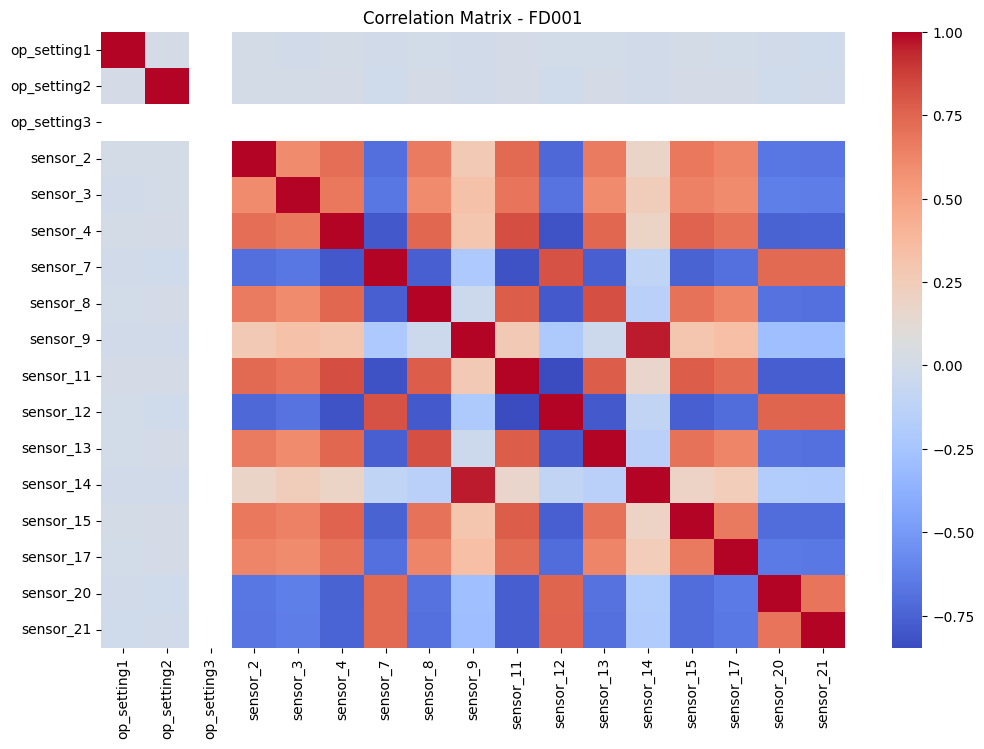

Saved: processed_data/FD001_processed.csv
Sliding window shape: (16631, 680)
Saved sliding windows: sliding_windows/FD001_X.csv sliding_windows/FD001_y.csv

Processing Dataset: FD002
Sensors removed: ['sensor_16']


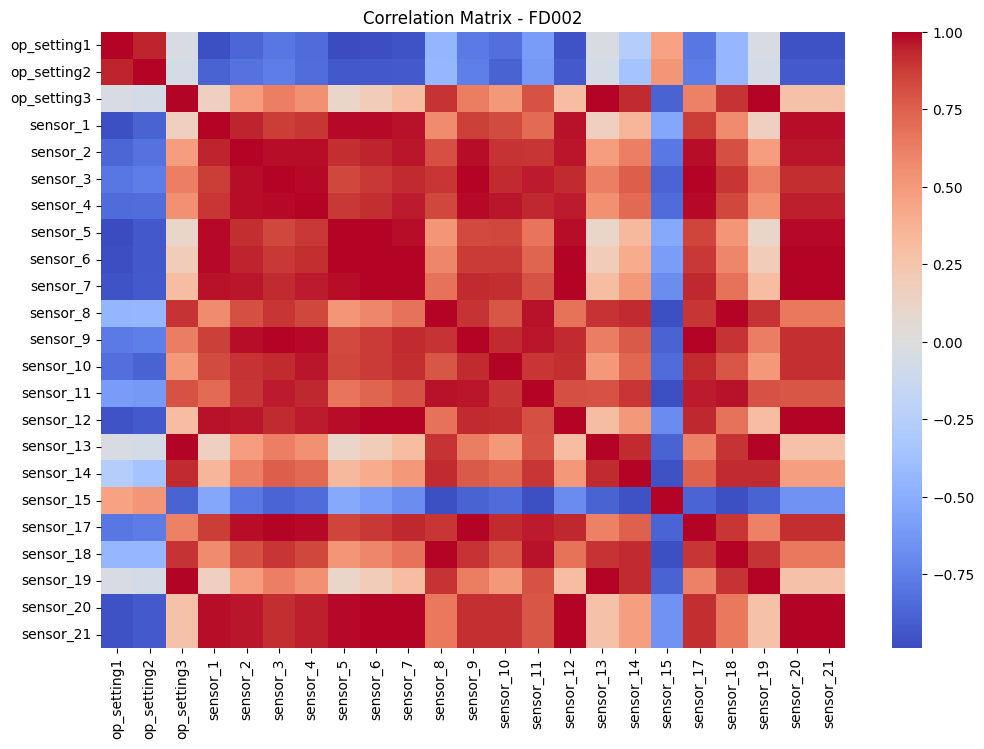

Saved: processed_data/FD002_processed.csv
Sliding window shape: (43359, 920)
Saved sliding windows: sliding_windows/FD002_X.csv sliding_windows/FD002_y.csv

Processing Dataset: FD003
Sensors removed: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


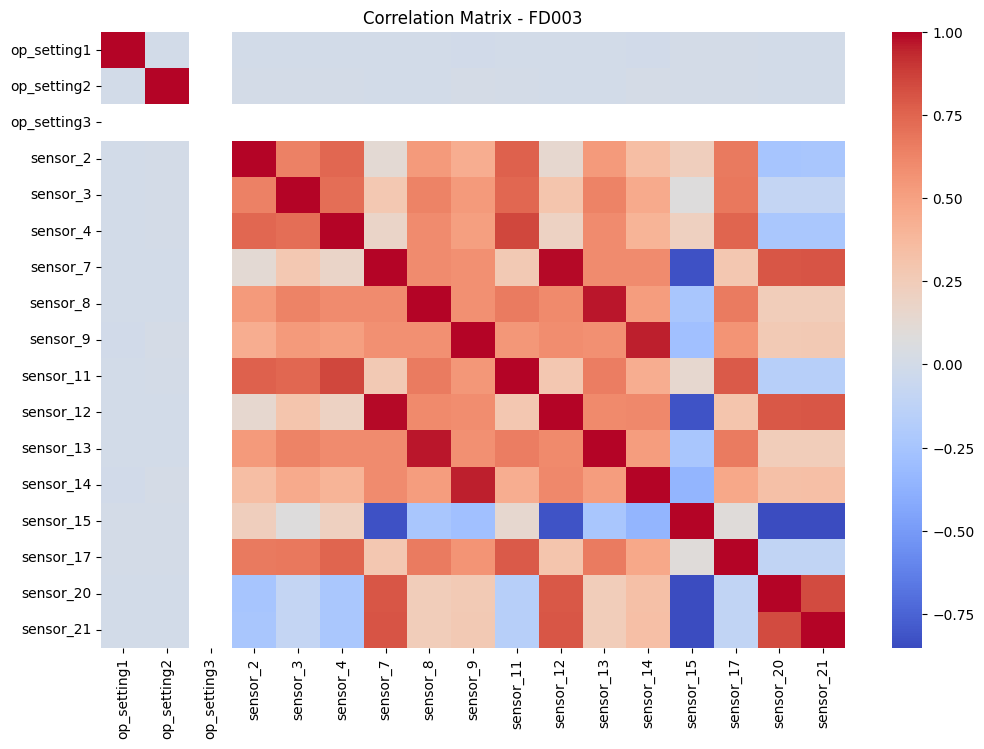

Saved: processed_data/FD003_processed.csv
Sliding window shape: (20720, 680)
Saved sliding windows: sliding_windows/FD003_X.csv sliding_windows/FD003_y.csv

Processing Dataset: FD004
Sensors removed: ['sensor_16']


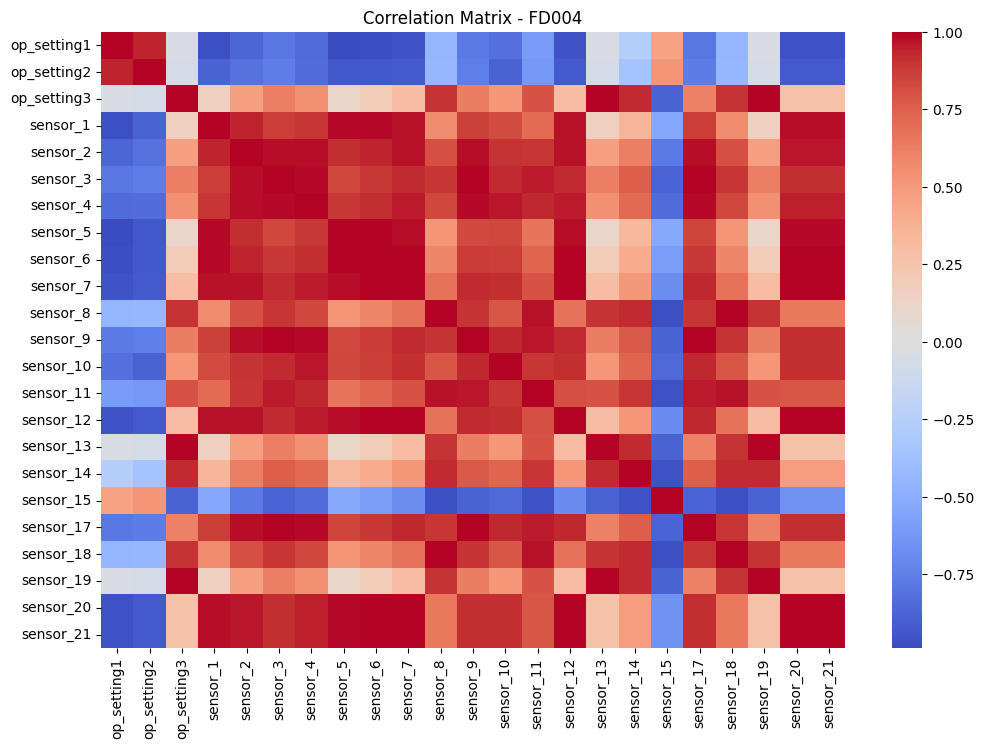

Saved: processed_data/FD004_processed.csv
Sliding window shape: (51289, 920)
Saved sliding windows: sliding_windows/FD004_X.csv sliding_windows/FD004_y.csv


In [ ]:
processed_datasets = {}

for name, path in datasets.items():

    processed_datasets[name] = process_dataset(name, path)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# ------------------------------
# FUNCTION TO RUN MODEL
# ------------------------------
def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    # ------------------------------
    # Load data
    # ------------------------------
    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    # ------------------------------
    # Train-Test Split (70:30)
    # ------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # ------------------------------
    # Build Model
    # ------------------------------
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)  # Output layer
    ])

#    model = Sequential([
#    Dense(128, activation='relu', input_shape=(X.shape[1],)),
#    Dropout(0.2),
#    Dense(64, activation='relu'),
#    Dropout(0.2),
#    Dense(32, activation='relu'),
#    Dense(1)
#    ])

    # ------------------------------
    # Compile Model
    # ------------------------------
    model.compile(
        optimizer='adam',
        loss='mse'
    )

    # ------------------------------
    # Train Model
    # ------------------------------
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        verbose=2
    )

    # ------------------------------
    # Predict & Evaluate
    # ------------------------------
    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE ({dataset_name}): {rmse:.4f}")

    return rmse

# ------------------------------
# RUN FOR FD001 & FD004
# ------------------------------
rmse_fd001 = run_model("FD001")
rmse_fd004 = run_model("FD004")

print("\nFinal Results:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


Dataset: FD001
Epoch 1/50
364/364 - 1s - loss: 1672.9135 - 1s/epoch - 3ms/step
Epoch 2/50
364/364 - 0s - loss: 573.8581 - 462ms/epoch - 1ms/step
Epoch 3/50
364/364 - 0s - loss: 245.6246 - 472ms/epoch - 1ms/step
Epoch 4/50
364/364 - 0s - loss: 165.7767 - 460ms/epoch - 1ms/step
Epoch 5/50
364/364 - 0s - loss: 132.9313 - 457ms/epoch - 1ms/step
Epoch 6/50
364/364 - 0s - loss: 106.4947 - 459ms/epoch - 1ms/step
Epoch 7/50
364/364 - 1s - loss: 88.2138 - 513ms/epoch - 1ms/step
Epoch 8/50
364/364 - 1s - loss: 73.1967 - 552ms/epoch - 2ms/step
Epoch 9/50
364/364 - 1s - loss: 62.6159 - 569ms/epoch - 2ms/step
Epoch 10/50
364/364 - 0s - loss: 51.1035 - 446ms/epoch - 1ms/step
Epoch 11/50
364/364 - 1s - loss: 43.6400 - 657ms/epoch - 2ms/step
Epoch 12/50
364/364 - 1s - loss: 38.4274 - 620ms/epoch - 2ms/step
Epoch 13/50
364/364 - 0s - loss: 32.7238 - 454ms/epoch - 1ms/step
Epoch 14/50
364/364 - 0s - loss: 28.4208 - 456ms/epoch - 1ms/step
Epoch 15/50
364/364 - 0s - loss: 25.2958 - 468ms/epoch - 1ms/step

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 🔥 Updated Model (3 hidden layers)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),   # new layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=2)

    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE ({dataset_name}): {rmse:.4f}")

    return rmse

rmse_fd001 = run_model("FD001")
rmse_fd004 = run_model("FD004")

print("\nFinal Results with 10 Epochs, relu fn:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


Dataset: FD001
Epoch 1/10
182/182 - 1s - loss: 1730.9707 - 637ms/epoch - 4ms/step
Epoch 2/10
182/182 - 0s - loss: 450.9615 - 219ms/epoch - 1ms/step
Epoch 3/10
182/182 - 0s - loss: 211.4733 - 228ms/epoch - 1ms/step
Epoch 4/10
182/182 - 0s - loss: 154.1672 - 236ms/epoch - 1ms/step
Epoch 5/10
182/182 - 0s - loss: 121.0960 - 236ms/epoch - 1ms/step
Epoch 6/10
182/182 - 0s - loss: 100.6711 - 235ms/epoch - 1ms/step
Epoch 7/10
182/182 - 0s - loss: 77.3367 - 256ms/epoch - 1ms/step
Epoch 8/10
182/182 - 0s - loss: 66.0286 - 241ms/epoch - 1ms/step
Epoch 9/10
182/182 - 0s - loss: 53.8979 - 219ms/epoch - 1ms/step
Epoch 10/10
182/182 - 0s - loss: 48.1476 - 222ms/epoch - 1ms/step
156/156 [==============================] - 0s 895us/step
RMSE (FD001): 14.6316

Dataset: FD004
Epoch 1/10
561/561 - 1s - loss: 1573.4320 - 1s/epoch - 2ms/step
Epoch 2/10
561/561 - 1s - loss: 778.6033 - 697ms/epoch - 1ms/step
Epoch 3/10
561/561 - 1s - loss: 657.6068 - 701ms/epoch - 1ms/step
Epoch 4/10
561/561 - 1s - loss: 583

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 🔥 Updated Model (3 hidden layers)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),   # new layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=2)

    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE ({dataset_name}): {rmse:.4f}")

    return rmse

rmse_fd001 = run_model("FD001")
rmse_fd004 = run_model("FD004")

print("\nFinal Results with 20 Epochs, relu fn:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


Dataset: FD001
Epoch 1/20
182/182 - 1s - loss: 2061.3542 - 626ms/epoch - 3ms/step
Epoch 2/20
182/182 - 0s - loss: 570.5391 - 238ms/epoch - 1ms/step
Epoch 3/20
182/182 - 0s - loss: 236.0359 - 214ms/epoch - 1ms/step
Epoch 4/20
182/182 - 0s - loss: 168.2276 - 238ms/epoch - 1ms/step
Epoch 5/20
182/182 - 0s - loss: 126.6034 - 233ms/epoch - 1ms/step
Epoch 6/20
182/182 - 0s - loss: 103.0713 - 217ms/epoch - 1ms/step
Epoch 7/20
182/182 - 0s - loss: 83.6073 - 233ms/epoch - 1ms/step
Epoch 8/20
182/182 - 0s - loss: 71.6923 - 226ms/epoch - 1ms/step
Epoch 9/20
182/182 - 0s - loss: 60.3481 - 216ms/epoch - 1ms/step
Epoch 10/20
182/182 - 0s - loss: 48.2966 - 228ms/epoch - 1ms/step
Epoch 11/20
182/182 - 0s - loss: 42.0964 - 223ms/epoch - 1ms/step
Epoch 12/20
182/182 - 0s - loss: 35.0926 - 252ms/epoch - 1ms/step
Epoch 13/20
182/182 - 0s - loss: 32.9394 - 232ms/epoch - 1ms/step
Epoch 14/20
182/182 - 0s - loss: 26.1986 - 209ms/epoch - 1ms/step
Epoch 15/20
182/182 - 0s - loss: 23.7828 - 224ms/epoch - 1ms/s

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 🔥 Updated Model (3 hidden layers)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),   # new layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=2)

    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE ({dataset_name}): {rmse:.4f}")

    return rmse

rmse_fd001 = run_model("FD001")
rmse_fd004 = run_model("FD004")

print("\nFinal Results with relu fn:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


Dataset: FD001
Epoch 1/10
182/182 - 1s - loss: 1749.4745 - 625ms/epoch - 3ms/step
Epoch 2/10
182/182 - 0s - loss: 516.2348 - 208ms/epoch - 1ms/step
Epoch 3/10
182/182 - 0s - loss: 220.4353 - 198ms/epoch - 1ms/step
Epoch 4/10
182/182 - 0s - loss: 158.8351 - 224ms/epoch - 1ms/step
Epoch 5/10
182/182 - 0s - loss: 123.9313 - 220ms/epoch - 1ms/step
Epoch 6/10
182/182 - 0s - loss: 101.6886 - 202ms/epoch - 1ms/step
Epoch 7/10
182/182 - 0s - loss: 82.6992 - 218ms/epoch - 1ms/step
Epoch 8/10
182/182 - 0s - loss: 70.0561 - 214ms/epoch - 1ms/step
Epoch 9/10
182/182 - 0s - loss: 56.2316 - 198ms/epoch - 1ms/step
Epoch 10/10
182/182 - 0s - loss: 44.2353 - 213ms/epoch - 1ms/step
156/156 [==============================] - 0s 713us/step
RMSE (FD001): 14.6023

Dataset: FD004
Epoch 1/10
561/561 - 1s - loss: 1652.0280 - 1s/epoch - 2ms/step
Epoch 2/10
561/561 - 1s - loss: 786.9675 - 734ms/epoch - 1ms/step
Epoch 3/10
561/561 - 1s - loss: 665.3899 - 735ms/epoch - 1ms/step
Epoch 4/10
561/561 - 1s - loss: 596

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 🔥 Updated Model (3 hidden layers)
    model = Sequential([
        Dense(128, activation='sigmoid', input_shape=(X.shape[1],)),
        Dense(64, activation='sigmoid'),
        Dense(32, activation='sigmoid'),   # new layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=2)

    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE ({dataset_name}): {rmse:.4f}")

    return rmse

rmse_fd001 = run_model("FD001")
rmse_fd004 = run_model("FD004")

print("\nFinal Results with sigmoid fn:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


Dataset: FD001
Epoch 1/10
182/182 - 1s - loss: 7130.8691 - 659ms/epoch - 4ms/step
Epoch 2/10
182/182 - 0s - loss: 6520.7490 - 260ms/epoch - 1ms/step
Epoch 3/10
182/182 - 0s - loss: 5975.0977 - 253ms/epoch - 1ms/step
Epoch 4/10
182/182 - 0s - loss: 5493.9038 - 250ms/epoch - 1ms/step
Epoch 5/10
182/182 - 0s - loss: 4982.0381 - 222ms/epoch - 1ms/step
Epoch 6/10
182/182 - 0s - loss: 4538.4683 - 200ms/epoch - 1ms/step
Epoch 7/10
182/182 - 0s - loss: 4151.4673 - 218ms/epoch - 1ms/step
Epoch 8/10
182/182 - 0s - loss: 3753.9802 - 250ms/epoch - 1ms/step
Epoch 9/10
182/182 - 0s - loss: 3403.9756 - 219ms/epoch - 1ms/step
Epoch 10/10
182/182 - 0s - loss: 3091.3447 - 251ms/epoch - 1ms/step
156/156 [==============================] - 0s 867us/step
RMSE (FD001): 54.4150

Dataset: FD004
Epoch 1/10
561/561 - 2s - loss: 7670.6367 - 2s/epoch - 3ms/step
Epoch 2/10
561/561 - 1s - loss: 5937.4248 - 904ms/epoch - 2ms/step
Epoch 3/10
561/561 - 1s - loss: 4655.6821 - 1s/epoch - 2ms/step
Epoch 4/10
561/561 - 1s


Dataset: FD001
Epoch 1/10
182/182 - 1s - loss: 2237.3196 - 612ms/epoch - 3ms/step
Epoch 2/10
182/182 - 0s - loss: 824.9918 - 215ms/epoch - 1ms/step
Epoch 3/10
182/182 - 0s - loss: 326.6220 - 202ms/epoch - 1ms/step
Epoch 4/10
182/182 - 0s - loss: 191.2696 - 220ms/epoch - 1ms/step
Epoch 5/10
182/182 - 0s - loss: 149.2300 - 218ms/epoch - 1ms/step
Epoch 6/10
182/182 - 0s - loss: 120.2997 - 235ms/epoch - 1ms/step
Epoch 7/10
182/182 - 0s - loss: 100.7661 - 219ms/epoch - 1ms/step
Epoch 8/10
182/182 - 0s - loss: 81.1255 - 218ms/epoch - 1ms/step
Epoch 9/10
182/182 - 0s - loss: 73.3381 - 232ms/epoch - 1ms/step
Epoch 10/10
182/182 - 0s - loss: 59.2449 - 219ms/epoch - 1ms/step
156/156 [==============================] - 0s 853us/step


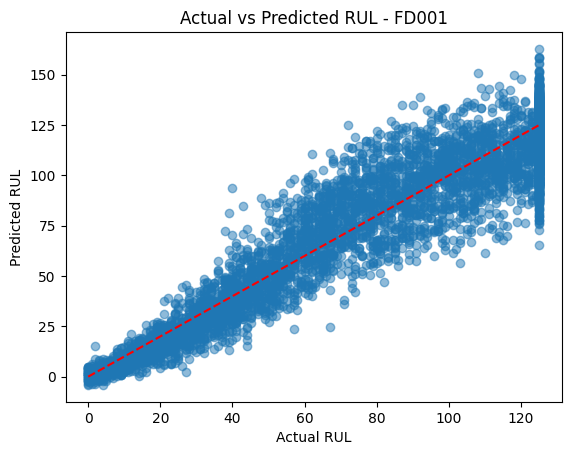

Training RMSE (FD001): 7.6971
Test RMSE (FD001): 14.3651

Dataset: FD004
Epoch 1/10
561/561 - 1s - loss: 1738.6736 - 1s/epoch - 3ms/step
Epoch 2/10
561/561 - 1s - loss: 809.1379 - 731ms/epoch - 1ms/step
Epoch 3/10
561/561 - 1s - loss: 685.8801 - 734ms/epoch - 1ms/step
Epoch 4/10
561/561 - 1s - loss: 601.9470 - 734ms/epoch - 1ms/step
Epoch 5/10
561/561 - 1s - loss: 548.0635 - 745ms/epoch - 1ms/step
Epoch 6/10
561/561 - 1s - loss: 507.5141 - 764ms/epoch - 1ms/step
Epoch 7/10
561/561 - 1s - loss: 477.5349 - 742ms/epoch - 1ms/step
Epoch 8/10
561/561 - 1s - loss: 453.1166 - 743ms/epoch - 1ms/step
Epoch 9/10
561/561 - 1s - loss: 432.5873 - 733ms/epoch - 1ms/step
Epoch 10/10
561/561 - 1s - loss: 417.2929 - 784ms/epoch - 1ms/step
481/481 [==============================] - 0s 855us/step


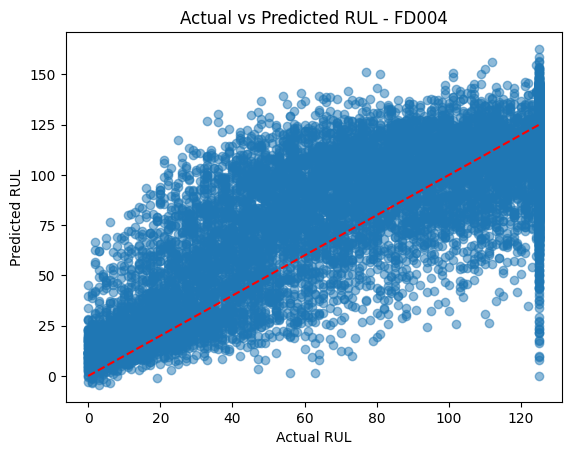

Training RMSE (FD004): 20.4277
Test RMSE (FD004): 25.0080

Final Results 3 layers 100 epochs with relu fn:
FD001 RMSE: 14.3651
FD004 RMSE: 25.0080


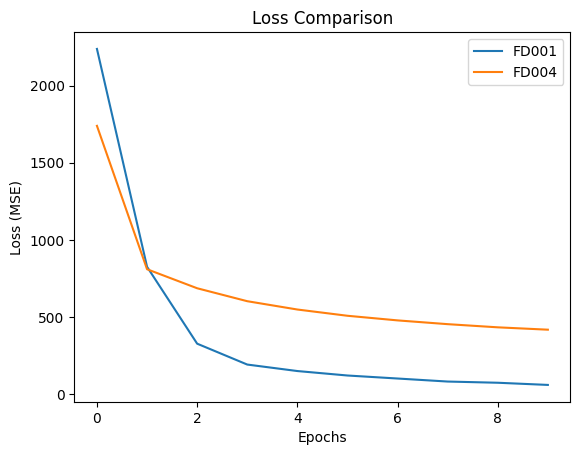

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def run_model(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    X = pd.read_csv(f"sliding_windows/{dataset_name}_X.csv").values
    y = pd.read_csv(f"sliding_windows/{dataset_name}_y.csv").values.flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 🔥 Updated Model (3 hidden layers)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),   # new layer
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    history = model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=2)

    # Training error
    train_mse = history.history['loss'][-1]
    train_rmse = np.sqrt(train_mse)

    y_pred = model.predict(X_test).flatten()

    plt.figure()

    plt.scatter(y_test, y_pred, alpha=0.5)

    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.title(f'Actual vs Predicted RUL - {dataset_name}')

    # 🔥 Perfect prediction line
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')

    plt.show()

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"Training RMSE ({dataset_name}): {train_rmse:.4f}")
    print(f"Test RMSE ({dataset_name}): {test_rmse:.4f}")

    return test_rmse, history

rmse_fd001, history_fd001 = run_model("FD001")
rmse_fd004, history_fd004 = run_model("FD004")

print("\nFinal Results 3 layers 100 epochs with relu fn:")
print(f"FD001 RMSE: {rmse_fd001:.4f}")
print(f"FD004 RMSE: {rmse_fd004:.4f}")


plt.figure()

plt.plot(history_fd001.history['loss'], label='FD001')
plt.plot(history_fd004.history['loss'], label='FD004')

plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Comparison')
plt.legend()

plt.show()